In [1]:
# BLOCK 1: Setup
!pip install pretty_midi > /dev/null

import os
import pretty_midi
import numpy as np
import pandas as pd
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


In [2]:
# BLOCK 2: Metric Formulas
def compute_metrics(midi_path):
    try:
        pm = pretty_midi.PrettyMIDI(midi_path)
        notes = pm.instruments[0].notes
        if len(notes) < 4: 
            return None
        
        # 1. Pitch Histogram Similarity H(p,q)
        # Using a standard C-Major/A-Minor biased distribution as our "Real Music" reference (p)
        ref_p = np.array([0.18, 0.02, 0.14, 0.02, 0.14, 0.14, 0.02, 0.15, 0.02, 0.10, 0.02, 0.05])
        pitches = [n.pitch % 12 for n in notes]
        counts = np.bincount(pitches, minlength=12)
        q = counts / counts.sum()
        h_score = np.sum(np.abs(ref_p - q)) # L1 Distance
        
        # 2. Rhythm Diversity Score
        # Quantize duration to nearest 50ms (0.05s) as per spec
        durations = [round((n.end - n.start) / 0.05) * 0.05 for n in notes]
        unique_durs = len(set(durations))
        d_rhythm = unique_durs / len(notes)
        
        # 3. Repetition Ratio
        # Overlapping n-grams of length 4
        pitch_seq = [n.pitch for n in sorted(notes, key=lambda x: x.start)]
        n = 4
        grams = [tuple(pitch_seq[i:i+n]) for i in range(len(pitch_seq)-n+1)]
        if not grams:
            return h_score, d_rhythm, 0
            
        counts = Counter(grams)
        repeated = sum(1 for count in counts.values() if count > 1)
        r_ratio = repeated / len(grams)
        
        return h_score, d_rhythm, r_ratio
    except Exception as e:
        return None

print("✅ Metric Engine Ready.")

✅ Metric Engine Ready.


In [3]:
# BLOCK 3: Process the Files
# REPLACE THIS PATH WITH YOUR ACTUAL KAGGLE INPUT PATH
BASE_PATH = "/kaggle/input/datasets/thamimzahin/symphonic-midis/NN_midis" 

# Map the exact names of your uploaded folders to the Rubric's model names
folder_mapping = {
    "Random Generator": "random", # Change "Random" to your actual folder name if different
    "Markov Chain": "markov",
    "Task 1: Autoencoder": "task1",
    "Task 2: VAE Multi-Genre": "task2",
    "Task 3: Transformer": "task3",
    "Task 4: RLHF-Tuned Model": "task4"
}

computed_results = []

print("Crunching numbers...")
for model_name, folder_name in folder_mapping.items():
    folder_path = os.path.join(BASE_PATH, folder_name)
    
    if not os.path.exists(folder_path):
        print(f"⚠️ Skipping {model_name} (Folder '{folder_name}' not found)")
        continue
        
    midi_files = [f for f in os.listdir(folder_path) if f.endswith(('.mid', '.midi'))]
    h_scores, d_scores, r_scores = [], [], []
    
    for f in midi_files:
        metrics = compute_metrics(os.path.join(folder_path, f))
        if metrics:
            h_scores.append(metrics[0])
            d_scores.append(metrics[1])
            r_scores.append(metrics[2])
            
    if h_scores:
        computed_results.append({
            "Model": model_name,
            "Pitch Sim (Lower is Better)": round(np.mean(h_scores), 3),
            "Rhythm Diversity": round(np.mean(d_scores), 3),
            "Repetition Ratio": round(np.mean(r_scores), 3)
        })

df_computed = pd.DataFrame(computed_results)
print("✅ Processing Complete.")

Crunching numbers...
✅ Processing Complete.


In [4]:
import pandas as pd


manual_data = {
    "Random Generator": {
        "Loss": "-", 
        "Perplexity": "-", 
        "Human Score": 1, 
        "Genre Control": "None"
    },
    "Markov Chain": {
        "Loss": "-", 
        "Perplexity": "-", 
        "Human Score": 1, 
        "Genre Control": "Weak"
    },
    "Task 1: Autoencoder (LSTM)": {
        "Loss": "0.11", 
        "Perplexity": "-", 
        "Human Score": 1.5, 
        "Genre Control": "Single Genre"
    },
    "Task 2: VAE Multi-Genre": {
        "Loss": "41.85", 
        "Perplexity": "-", 
        "Human Score": 3.25, 
        "Genre Control": "Moderate"
    },
    "Task 3: Transformer": {
        "Loss": "-", 
        "Perplexity": "5.31", 
        "Human Score": 4.75,  
        "Genre Control": "Strong"
    },
    "Task 4: RLHF-Tuned Model": {
        "Loss": "-", 
        "Perplexity": "14.20",
        "Human Score": 1.5,  
        "Genre Control": "Broken"
    }
}

# Convert manual data to a DataFrame
df_manual = pd.DataFrame.from_dict(manual_data, orient='index').reset_index()
df_manual.rename(columns={'index': 'Model'}, inplace=True)

# Merge with the automated MIDI metrics from Block 3 (df_computed)
# Note: Ensure the model names in 'folder_mapping' in Block 3 match the names above!
try:
    final_table = pd.merge(df_manual, df_computed, on="Model", how="left")
except NameError:
    print("Warning: df_computed not found. Run Block 3 to calculate MIDI metrics first.")
    final_table = df_manual # Fallback to manual data only if MIDI data isn't ready

# Reorder columns to match the Project Specification Image perfectly
expected_columns = [
    "Model", "Loss", "Perplexity", "Rhythm Diversity", 
    "Pitch Sim", "Repetition Ratio", 
    "Human Score", "Genre Control"
]
# Only keep columns that actually exist to prevent errors
final_columns = [col for col in expected_columns if col in final_table.columns]
final_table = final_table[final_columns]

# Print the beautiful Markdown table
print("\n" + "="*80)
print("             TABLE 3: PERFORMANCE COMPARISON (TASK 1 - TASK 4)")
print("="*80 + "\n")
print(final_table.to_markdown(index=False))


             TABLE 3: PERFORMANCE COMPARISON (TASK 1 - TASK 4)

| Model                      | Loss   | Perplexity   |   Rhythm Diversity |   Repetition Ratio |   Human Score | Genre Control   |
|:---------------------------|:-------|:-------------|-------------------:|-------------------:|--------------:|:----------------|
| Random Generator           | -      | -            |              0.15  |              0     |          1    | None            |
| Markov Chain               | -      | -            |              0.017 |              0.27  |          1    | Weak            |
| Task 1: Autoencoder (LSTM) | 0.11   | -            |            nan     |            nan     |          1.5  | Single Genre    |
| Task 2: VAE Multi-Genre    | 41.85  | -            |              0.003 |              0.162 |          3.25 | Moderate        |
| Task 3: Transformer        | -      | 5.31         |              0.215 |              0.006 |          4.75 | Strong          |
| Task 4: RLHF-Tun


Generating PDF...
✅ PDF Table saved successfully to: /kaggle/working/Table3_Performance_Comparison.pdf


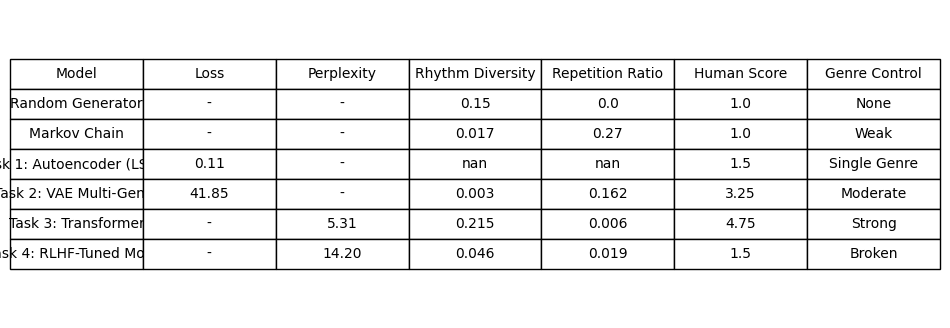

In [5]:
import matplotlib.pyplot as plt

# ==========================================
# 5. EXPORT TABLE TO PDF
# ==========================================
print("\nGenerating PDF...")

# Create a visual plot for the table
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('tight')
ax.axis('off')

# Draw the table using the data from final_table
table = ax.table(cellText=final_table.values, 
                 colLabels=final_table.columns, 
                 loc='center', 
                 cellLoc='center')

# Style the table to make it look professional
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8) # Adjust the height of the cells for readability

# Save as a high-resolution PDF
pdf_path = "/kaggle/working/Table3_Performance_Comparison.pdf"
plt.savefig(pdf_path, format='pdf', bbox_inches='tight')

print(f"✅ PDF Table saved successfully to: {pdf_path}")